In [29]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
from ys import YardSaleModel, Taxation, WAARule

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


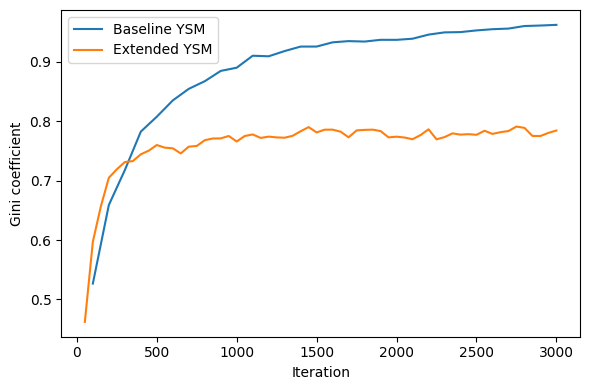

In [21]:
np.random.seed(42)

N_steps = 3000
Record_interval = 100

base = YardSaleModel(n_agents=100, f=0.1)
hist_base = base.run(n_steps=N_steps, record_interval=Record_interval)

ext = YardSaleModel(
    n_agents=100,
    f=0.1,
    transaction_rule=WAARule(zeta=0.2),
    taxation=Taxation(chi=0.001, mean_wealth = 1.0),
    initial_wealth = 1.0,
)
Record_interval = 50
hist_ext = ext.run(n_steps=N_steps, record_interval=Record_interval)

plt.figure(figsize=(6, 4))
plt.plot(hist_base[:, 0], hist_base[:, 1], label="Baseline YSM")
plt.plot(hist_ext[:, 0], hist_ext[:, 1], label="Extended YSM")
plt.xlabel("Iteration")
plt.ylabel("Gini coefficient")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
hist_ext = ext.run(n_steps=10, record_interval=1_000)

In [17]:
ext = YardSaleModel(
    n_agents=1_000,
    f=0.1,
    transaction_rule=WAARule(zeta=0.2),
    taxation=Taxation(chi=0.001, mean_wealth = 1.0),
)
hist_ext = ext.run(n_steps=1_000, record_interval=50)


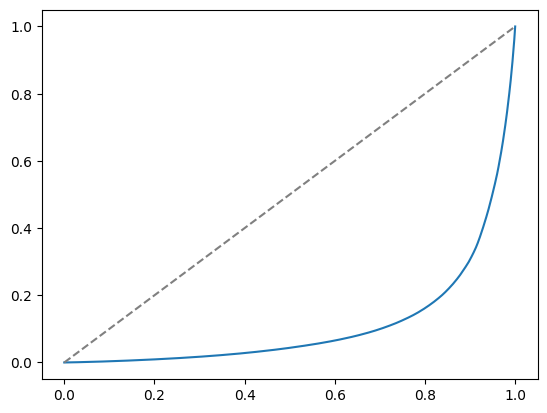

In [16]:
cum_wealth = np.cumsum(np.sort(ext.agents))
cum_wealth_normalized = cum_wealth / cum_wealth[-1]
population = np.linspace(0, 1, len(cum_wealth) + 1)
cum_wealth_normalized = np.insert(cum_wealth_normalized, 0, 0)

plt.plot(population, cum_wealth_normalized)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.show()

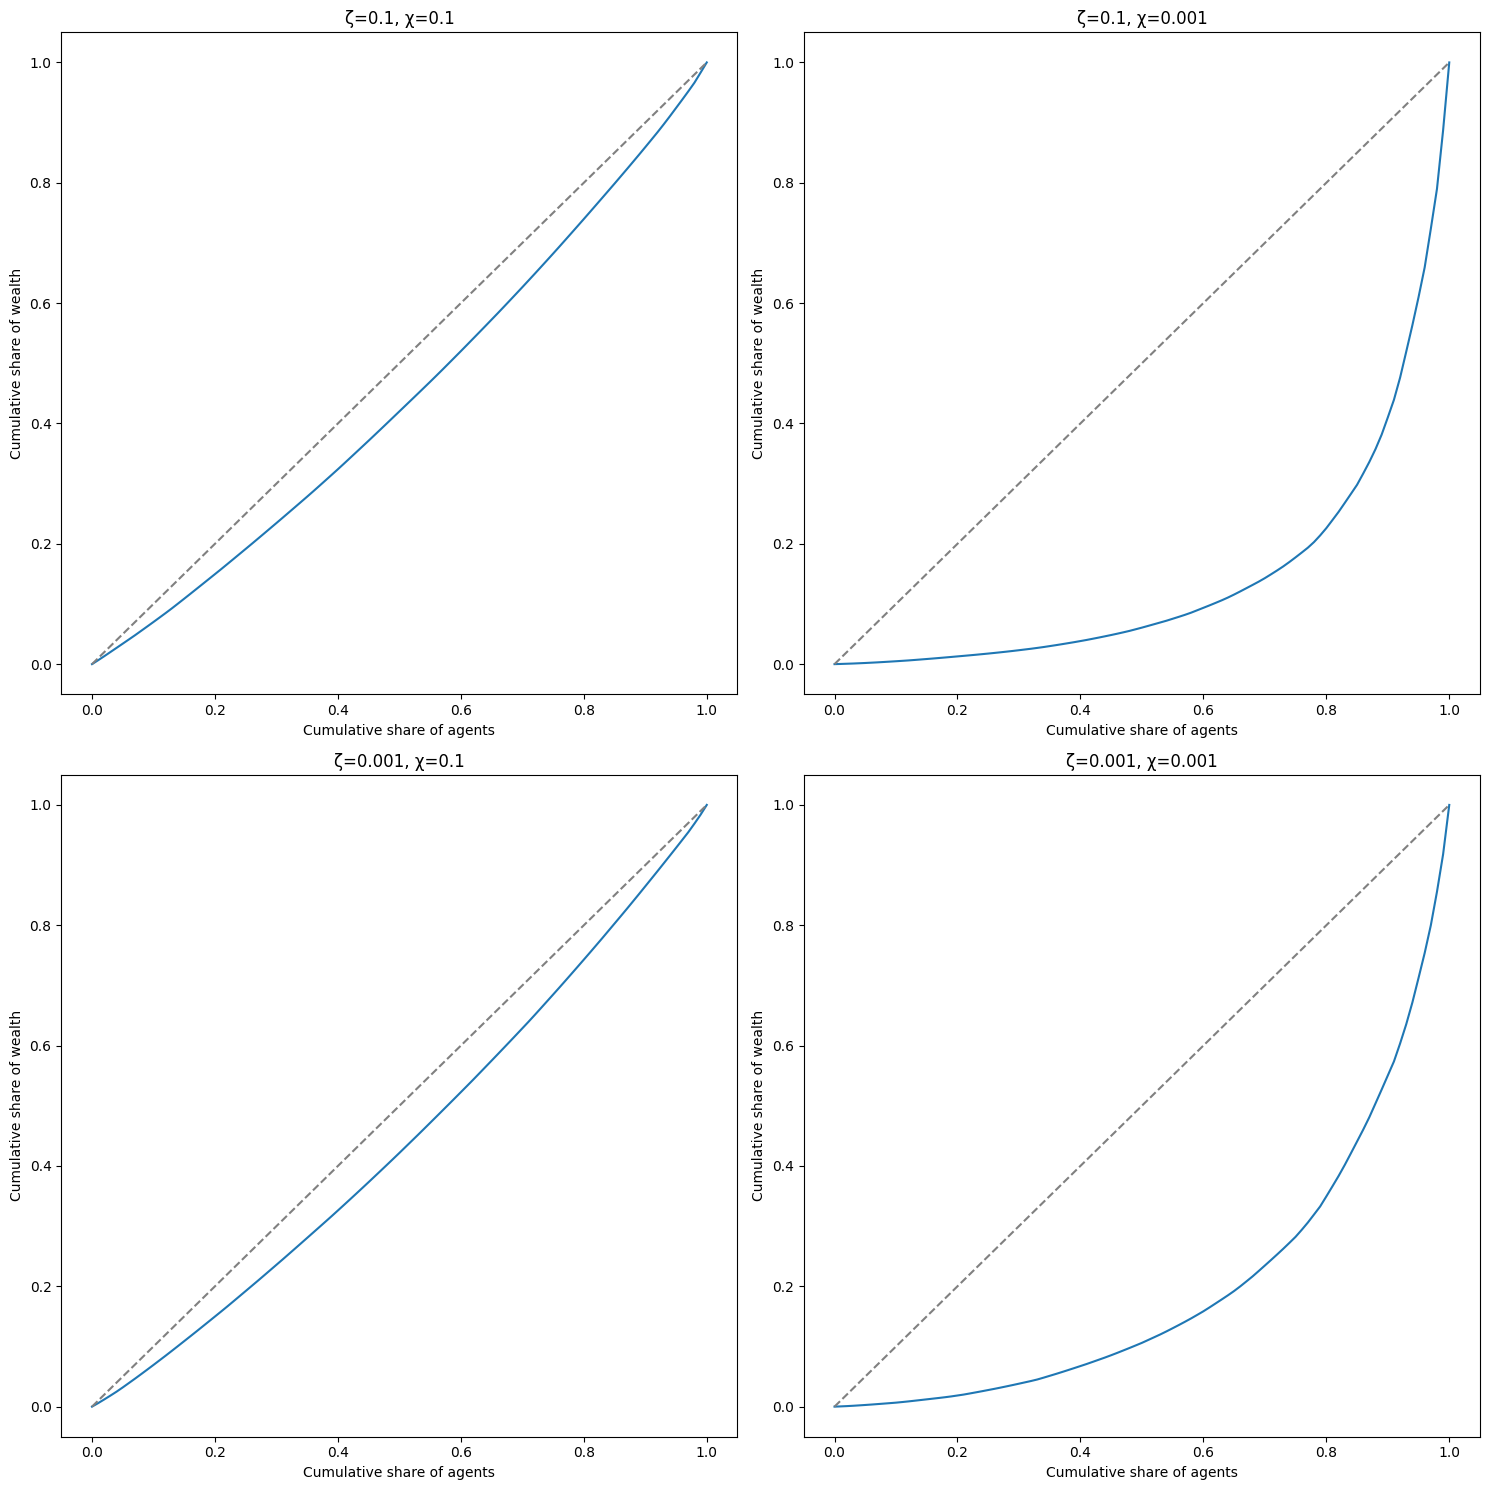

In [39]:
# zeta and chi values
zeta_values = [0.1, 0.001]
chi_values = [0.1, 0.001]

fig, axes = plt.subplots(2, 2, figsize=(15, 15))

for i, zeta in enumerate(zeta_values):
    for j, chi in enumerate(chi_values):
        
        ext = YardSaleModel(
            n_agents=100,
            initial_wealth= 1.0,
            f=0.1,
            transaction_rule=WAARule(zeta=zeta),
            taxation=Taxation(chi=chi, mean_wealth = 1.0),
        )
        ext.run(n_steps=2000, record_interval=300)

        wealth = ext.agents
        
        sorted_wealth = np.sort(wealth)
        cum_wealth = np.cumsum(sorted_wealth)
        cum_wealth_normalized = cum_wealth / cum_wealth[-1]
        population = np.linspace(0, 1, len(wealth) + 1)
        cum_wealth_normalized = np.insert(cum_wealth_normalized, 0, 0)

        # Plot the Lorenz curve
        axes[i, j].plot(population, cum_wealth_normalized)
        axes[i, j].plot([0, 1], [0, 1], linestyle="--", color="gray")
        axes[i, j].set_title(f'ζ={zeta}, χ={chi}')
        axes[i, j].set_xlabel('Cumulative share of agents')
        axes[i, j].set_ylabel('Cumulative share of wealth')

# Adjust layout
plt.tight_layout()
plt.show()
